# TDDE16 Project BBC news classification perfomrance between BERT and Naive Bayes and Logic regression
In this project I will use news categories from BBC which kaggle provides https://www.kaggle.com/competitions/learn-ai-bbc/overview

I will train and compare the performance of different techinques, namely googles BERT technology and some techinques performed in the lab


## 1: Fake new classification with Logic regression

In [2]:
#!pip3 install pandas
#!pip3 install spacy
#!pip3 install numpy

## Creating a Dataframe

In [54]:
# import the dataset and convert as a pandas dataframe
import pandas as pd
import spacy
import json
import numpy as np
nlp = spacy.load('en_core_web_sm')

df = pd.read_json('News_Category_Dataset_V3.json', lines=True)
#Drop unneccecary columns
df = df.drop(df.columns[[0, 4, 5]], axis=1) 
df.head(10)


,headline,category,short_description
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha..."
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to..."
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...
5,Cleaner Was Dead In Belk Bathroom For 4 Days B...,U.S. NEWS,The 63-year-old woman was seen working at the ...
6,Reporter Gets Adorable Surprise From Her Boyfr...,U.S. NEWS,"""Who's that behind you?"" an anchor for New Yor..."
7,Puerto Ricans Desperate For Water After Hurric...,WORLD NEWS,More than half a million people remained witho...
8,How A New Documentary Captures The Complexity ...,CULTURE & ARTS,"In ""Mija,"" director Isabel Castro combined mus..."
9,Biden At UN To Call Russian War An Affront To ...,WORLD NEWS,White House officials say the crux of the pres...


### Visualize the categories

In [36]:
len(set(df.category))
len(df.short_description)
#set(df.category)

209527

<AxesSubplot: >

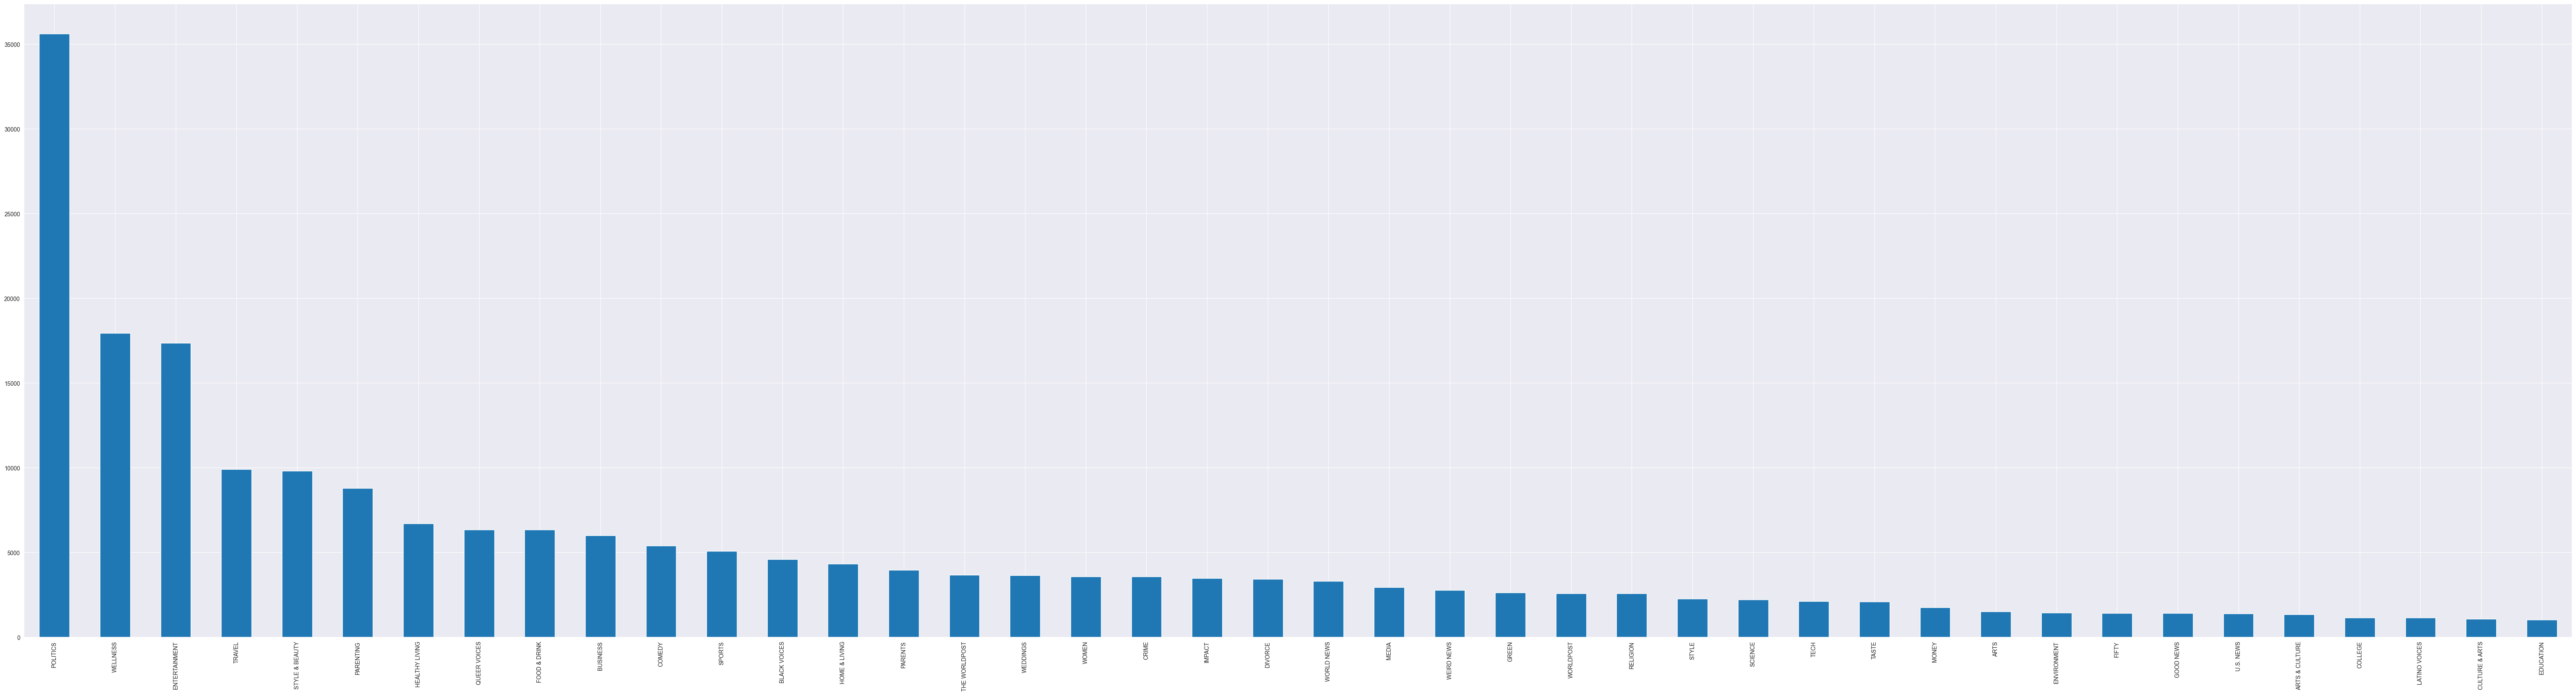

In [40]:
df.category.value_counts()
df.category.value_counts()[:42].plot(kind='bar')

It appears that the dataset is ubalanced with 35k topcis regarding politics and after that 18k with wellness

Many of the topics can also be concatinated because they are subtopics to each other or exatly the same.

Creating a more balanced set

In [55]:
df['category'].mask(df['category'] == 'ARTS', 'ARTS & CULTURE', inplace=True)
df['category'].mask(df['category'] == 'CULTURE & ARTS', 'ARTS & CULTURE', inplace=True)

df['category'].mask(df['category'] == 'COMEDY', 'ENTERTAINMENT', inplace=True)

df['category'].mask(df['category'] == 'TECH', 'TECH & SCIENCE', inplace=True)
df['category'].mask(df['category'] == 'SCIENCE', 'TECH & SCIENCE', inplace=True)

df['category'].mask(df['category'] == 'WORLDPOST', 'THE WORLDPOST', inplace=True)

df['category'].mask(df['category'] == 'STYLE', 'STYLE & BEAUTY', inplace=True)

df['category'].mask(df['category'] == 'PARENTING', 'PARENTS', inplace=True)


df['category'].mask(df['category'] == 'BLACK VOICES', 'VOICES', inplace=True)
df['category'].mask(df['category'] == 'LATINO VOICES', 'VOICES', inplace=True)
df['category'].mask(df['category'] == 'QUEER VOICES', 'VOICES', inplace=True)


In [56]:
#remove some of the politics to create more even dataset
def undersample(party):
    category = df[df.category == party].index
    random_indices = np.random.choice(category, 24000, replace=False)
    return df.loc[random_indices]
politics = undersample('POLITICS')


df = df.drop(df[df.category == "POLITICS"].index)
frames = [df, politics]

df = pd.concat(frames)

<AxesSubplot: >

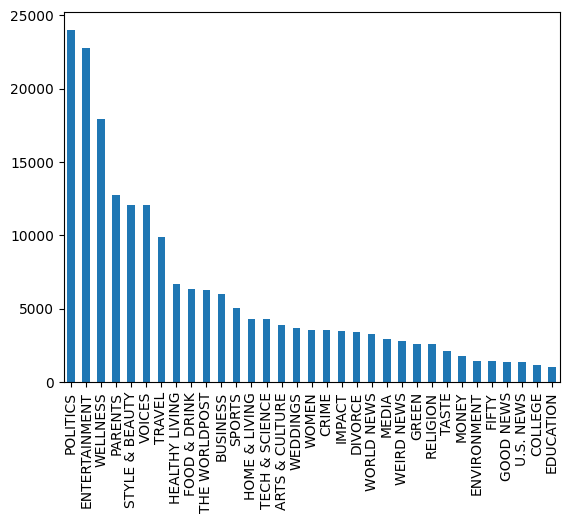

In [57]:
set(df.category)
len(df.short_description)
df.category.value_counts()
df.category.value_counts()[:42].plot(kind='bar')

### Create a test and training set

In [58]:
from sklearn.model_selection import train_test_split
X = df['short_description']
y = df['category']
#Create 
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, shuffle=True, random_state=42)

### Preprocess the data
A small preprocess is done to remove stop words, make sure it is alphabet and lemmatize all the words.

In [59]:
def preprocess(text):
    doc_list = []
    doc = nlp(text)
    for token in doc:
        if not token.is_stop and token.is_alpha:
                doc_list.append(token.lemma_)
            

    return doc_list

## Using naive bayes as a baseline

Now we will create a training and test set from the dataframe

Simmilar to the labs I will test the MultinomialNB with a count Vectorizer to show the score

In [60]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer


pipe = Pipeline(steps=[('countVec', TfidfVectorizer()), ('multNB', MultinomialNB())])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print(classification_report(y_test, pred))
 

/Users/simonjakobsson/Documents/School/Year5/TDDE16/TDDE16_project/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/simonjakobsson/Documents/School/Year5/TDDE16/TDDE16_project/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

ARTS & CULTURE       1.00      0.00      0.00       970
      BUSINESS       0.80      0.00      0.01      1459
       COLLEGE       0.00      0.00      0.00       267
         CRIME       1.00      0.00      0.00       912
       DIVORCE       1.00      0.00      0.01       843
     EDUCATION       0.00      0.00      0.00       267
 ENTERTAINMENT       0.33      0.55      0.41      5747
   ENVIRONMENT       0.00      0.00      0.00       375
         FIFTY       0.00      0.00      0.00       333
  FOOD & DRINK       0.65      0.14      0.23      1571
     GOOD NEWS       0.00      0.00      0.00       331
         GREEN       0.00      0.00      0.00       652
HEALTHY LIVING       1.00      0.00      0.00      1663
 HOME & LIVING       0.98      0.05      0.09      1100
        IMPACT       0.00      0.00      0.00       868
         MEDIA       0.00      0.00      0.00       739
         MONEY       0.00      0.00      0.00  

/Users/simonjakobsson/Documents/School/Year5/TDDE16/TDDE16_project/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Getting a baseline from dummytest

In [43]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X_train,y_train)
dummy_prediction = dummy_clf.predict(X_train)

print(classification_report(y_train, dummy_prediction))

                precision    recall  f1-score   support

ARTS & CULTURE       0.02      0.02      0.02      2971
      BUSINESS       0.02      0.03      0.03      4500
       COLLEGE       0.01      0.01      0.01       901
       DIVORCE       0.02      0.02      0.02      2599
     EDUCATION       0.01      0.01      0.01       762
 ENTERTAINMENT       0.12      0.12      0.12     19836
   ENVIRONMENT       0.01      0.01      0.01      1071
         FIFTY       0.00      0.00      0.00      1058
  FOOD & DRINK       0.03      0.03      0.03      4762
     GOOD NEWS       0.00      0.00      0.00      1053
         GREEN       0.01      0.01      0.01      1966
HEALTHY LIVING       0.03      0.03      0.03      5051
 HOME & LIVING       0.02      0.02      0.02      3239
        IMPACT       0.02      0.02      0.02      2635
         MEDIA       0.01      0.01      0.01      2190
         MONEY       0.01      0.01      0.01      1315
       PARENTS       0.06      0.06      0.06  

## Using logistic regression


In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer

pipe = Pipeline([('countVec', CountVectorizer()), ('logisticReg', LogisticRegression(max_iter=400))])
pipe.fit(X_train, y_train)
prediction = pipe.predict(X_test)
print(classification_report(y_test ,prediction))


/Users/simonjakobsson/Documents/School/Year5/TDDE16/TDDE16_project/env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                precision    recall  f1-score   support

ARTS & CULTURE       0.45      0.24      0.32       970
      BUSINESS       0.38      0.29      0.33      1459
       COLLEGE       0.34      0.15      0.20       267
         CRIME       0.39      0.26      0.31       912
       DIVORCE       0.69      0.54      0.61       843
     EDUCATION       0.35      0.15      0.21       267
 ENTERTAINMENT       0.32      0.69      0.43      5747
   ENVIRONMENT       0.42      0.22      0.29       375
         FIFTY       0.32      0.10      0.15       333
  FOOD & DRINK       0.52      0.51      0.52      1571
     GOOD NEWS       0.17      0.03      0.05       331
         GREEN       0.34      0.19      0.24       652
HEALTHY LIVING       0.18      0.12      0.15      1663
 HOME & LIVING       0.55      0.45      0.49      1100
        IMPACT       0.28      0.16      0.21       868
         MEDIA       0.38      0.16      0.23       739
         MONEY       0.40      0.28      0.33  

## Confusion matrix of the different baselines

/Users/simonjakobsson/Documents/School/Year5/TDDE16/TDDE16_project/env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


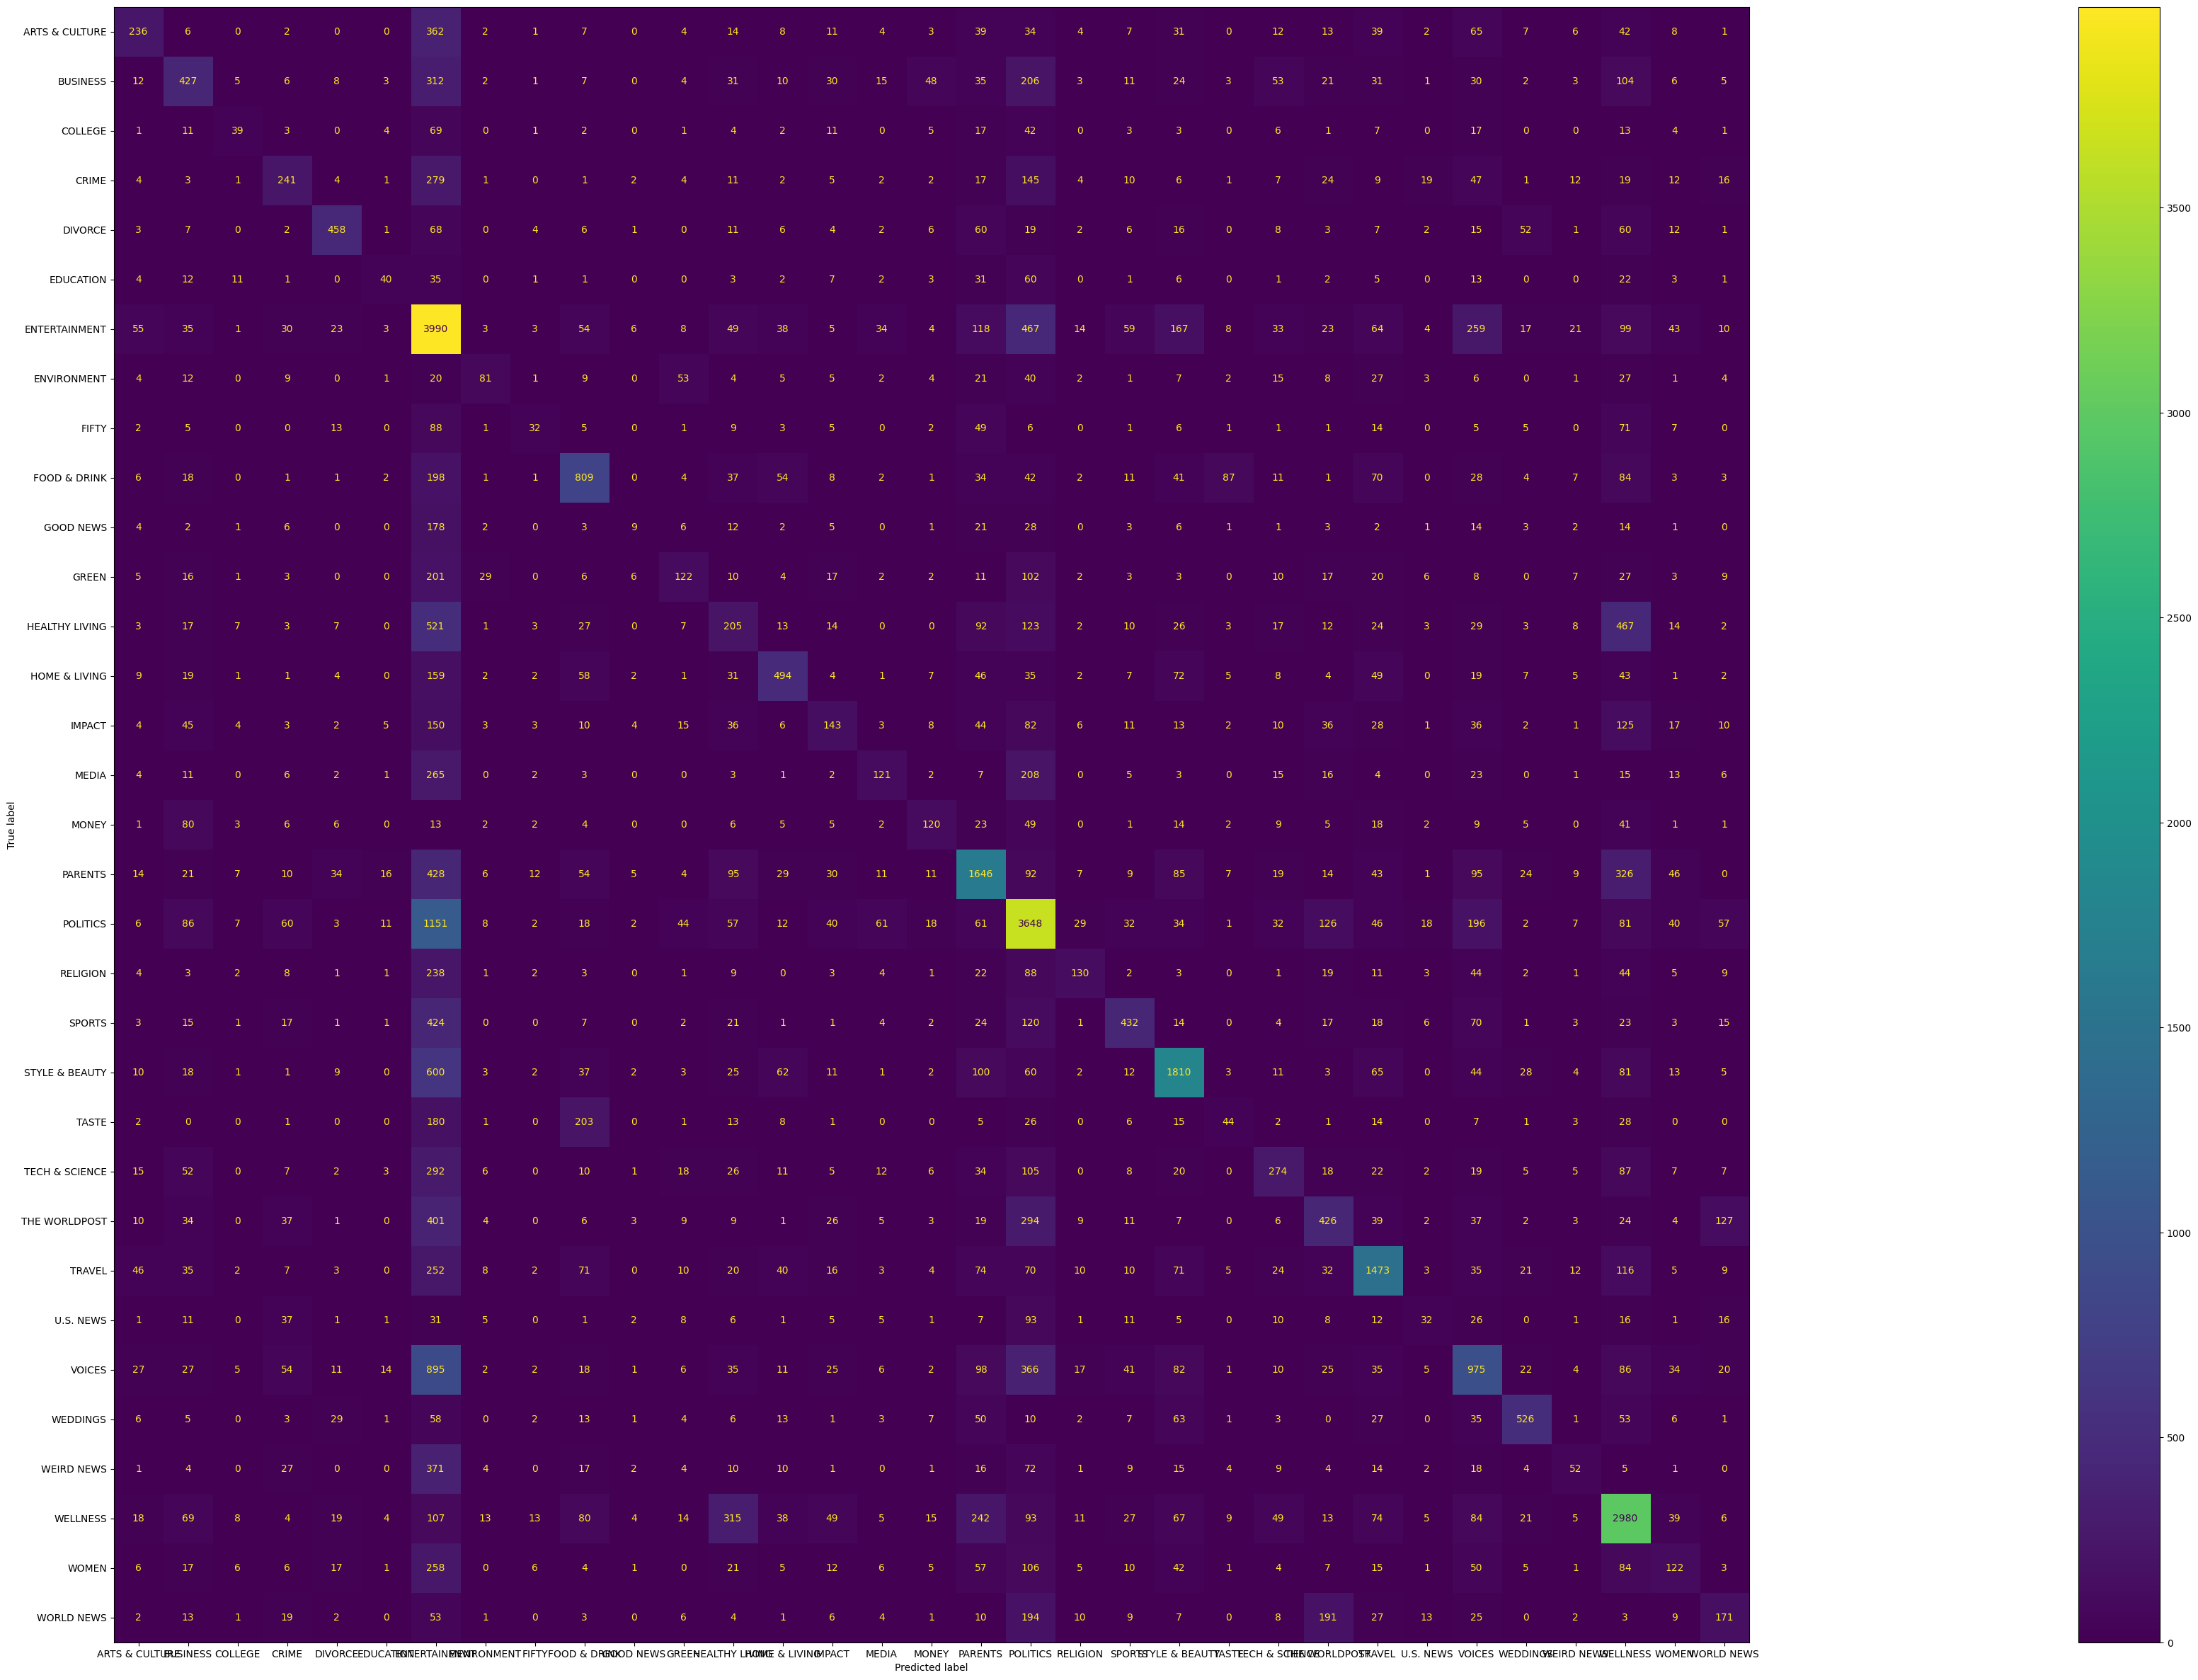

In [67]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix
import matplotlib.pyplot as plt

import seaborn as sns

fig, ax = plt.subplots(figsize=(120, 30))
plot_confusion_matrix(
    pipe,  # Fitted estimator (it must have been fit)
    X_test,
    y_test,  # test sets
    ax=ax,
);

## Using BERT to evaluate performance